# Part 2. Customer and returns

Notebook này tập trung vào return reason structure. Mục tiêu là chứng minh wrong size là vấn đề return cốt lõi, còn promo hầu như không thay đổi mix lý do trả hàng.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import Image, display, Markdown

ROOT = Path('/home/lducc/code/datathon')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'notebooks' / 'part2_eda') not in sys.path:
    sys.path.insert(0, str(ROOT / 'notebooks' / 'part2_eda'))

from models.data import load_dataframes, build_daily_frame, build_monthly_inventory_frame, build_segment_inventory_frame
from story_card_helpers import (
    setup_story_theme,
    create_story_card,
    apply_story_header,
    fill_footer,
    save_story_card,
    BLUE,
    ORANGE,
    RED,
    GREEN,
    GRAY,
)

setup_story_theme()
pd.options.display.float_format = lambda value: f"{value:,.2f}"
data = load_dataframes()
orders = data['orders'].copy()
returns = data['returns'].copy()
items = data['order_items'].copy()
products = data['products'].copy()
items['net_revenue'] = items['unit_price'] * items['quantity'] - items['discount_amount']
out_dir = ROOT / 'figures' / 'customer_and_returns'
out_dir.mkdir(parents=True, exist_ok=True)

items['promo_flag'] = items[['promo_id', 'promo_id_2']].notna().any(axis=1).astype(int)
promo_lookup = items.groupby(['order_id', 'product_id']).agg(promo_flag=('promo_flag', 'max')).reset_index()
returns = returns.merge(promo_lookup, on=['order_id', 'product_id'], how='left')
returns['promo_flag'] = returns['promo_flag'].fillna(0).astype(int)
returns['promo_label'] = np.where(returns['promo_flag'] == 1, 'Có promo', 'Không promo')

reason_order = ['wrong_size', 'defective', 'changed_mind', 'not_as_described', 'late_delivery']
refund_summary = returns.groupby(['return_reason', 'promo_label'])['refund_amount'].sum().rename('refund_amount').reset_index()
share_summary = refund_summary.copy()
share_summary['share_pct'] = share_summary.groupby('promo_label')['refund_amount'].transform(lambda values: values / values.sum() * 100)
display(refund_summary.pivot(index='return_reason', columns='promo_label', values='refund_amount').reindex(reason_order).round(2))



promo_label,Có promo,Không promo
return_reason,,
wrong_size,"58,410,901.80","118,276,298.95"
defective,"33,122,503.28","70,476,639.98"
changed_mind,"29,062,196.39","60,659,562.61"
not_as_described,"30,601,814.08","60,051,376.70"
late_delivery,"16,842,752.08","33,094,460.68"


## Wrong size mới là vấn đề return cốt lõi

Chart này vừa đo quy mô refund theo từng lý do vừa kiểm tra promo có đổi mix lý do trả hàng hay không.

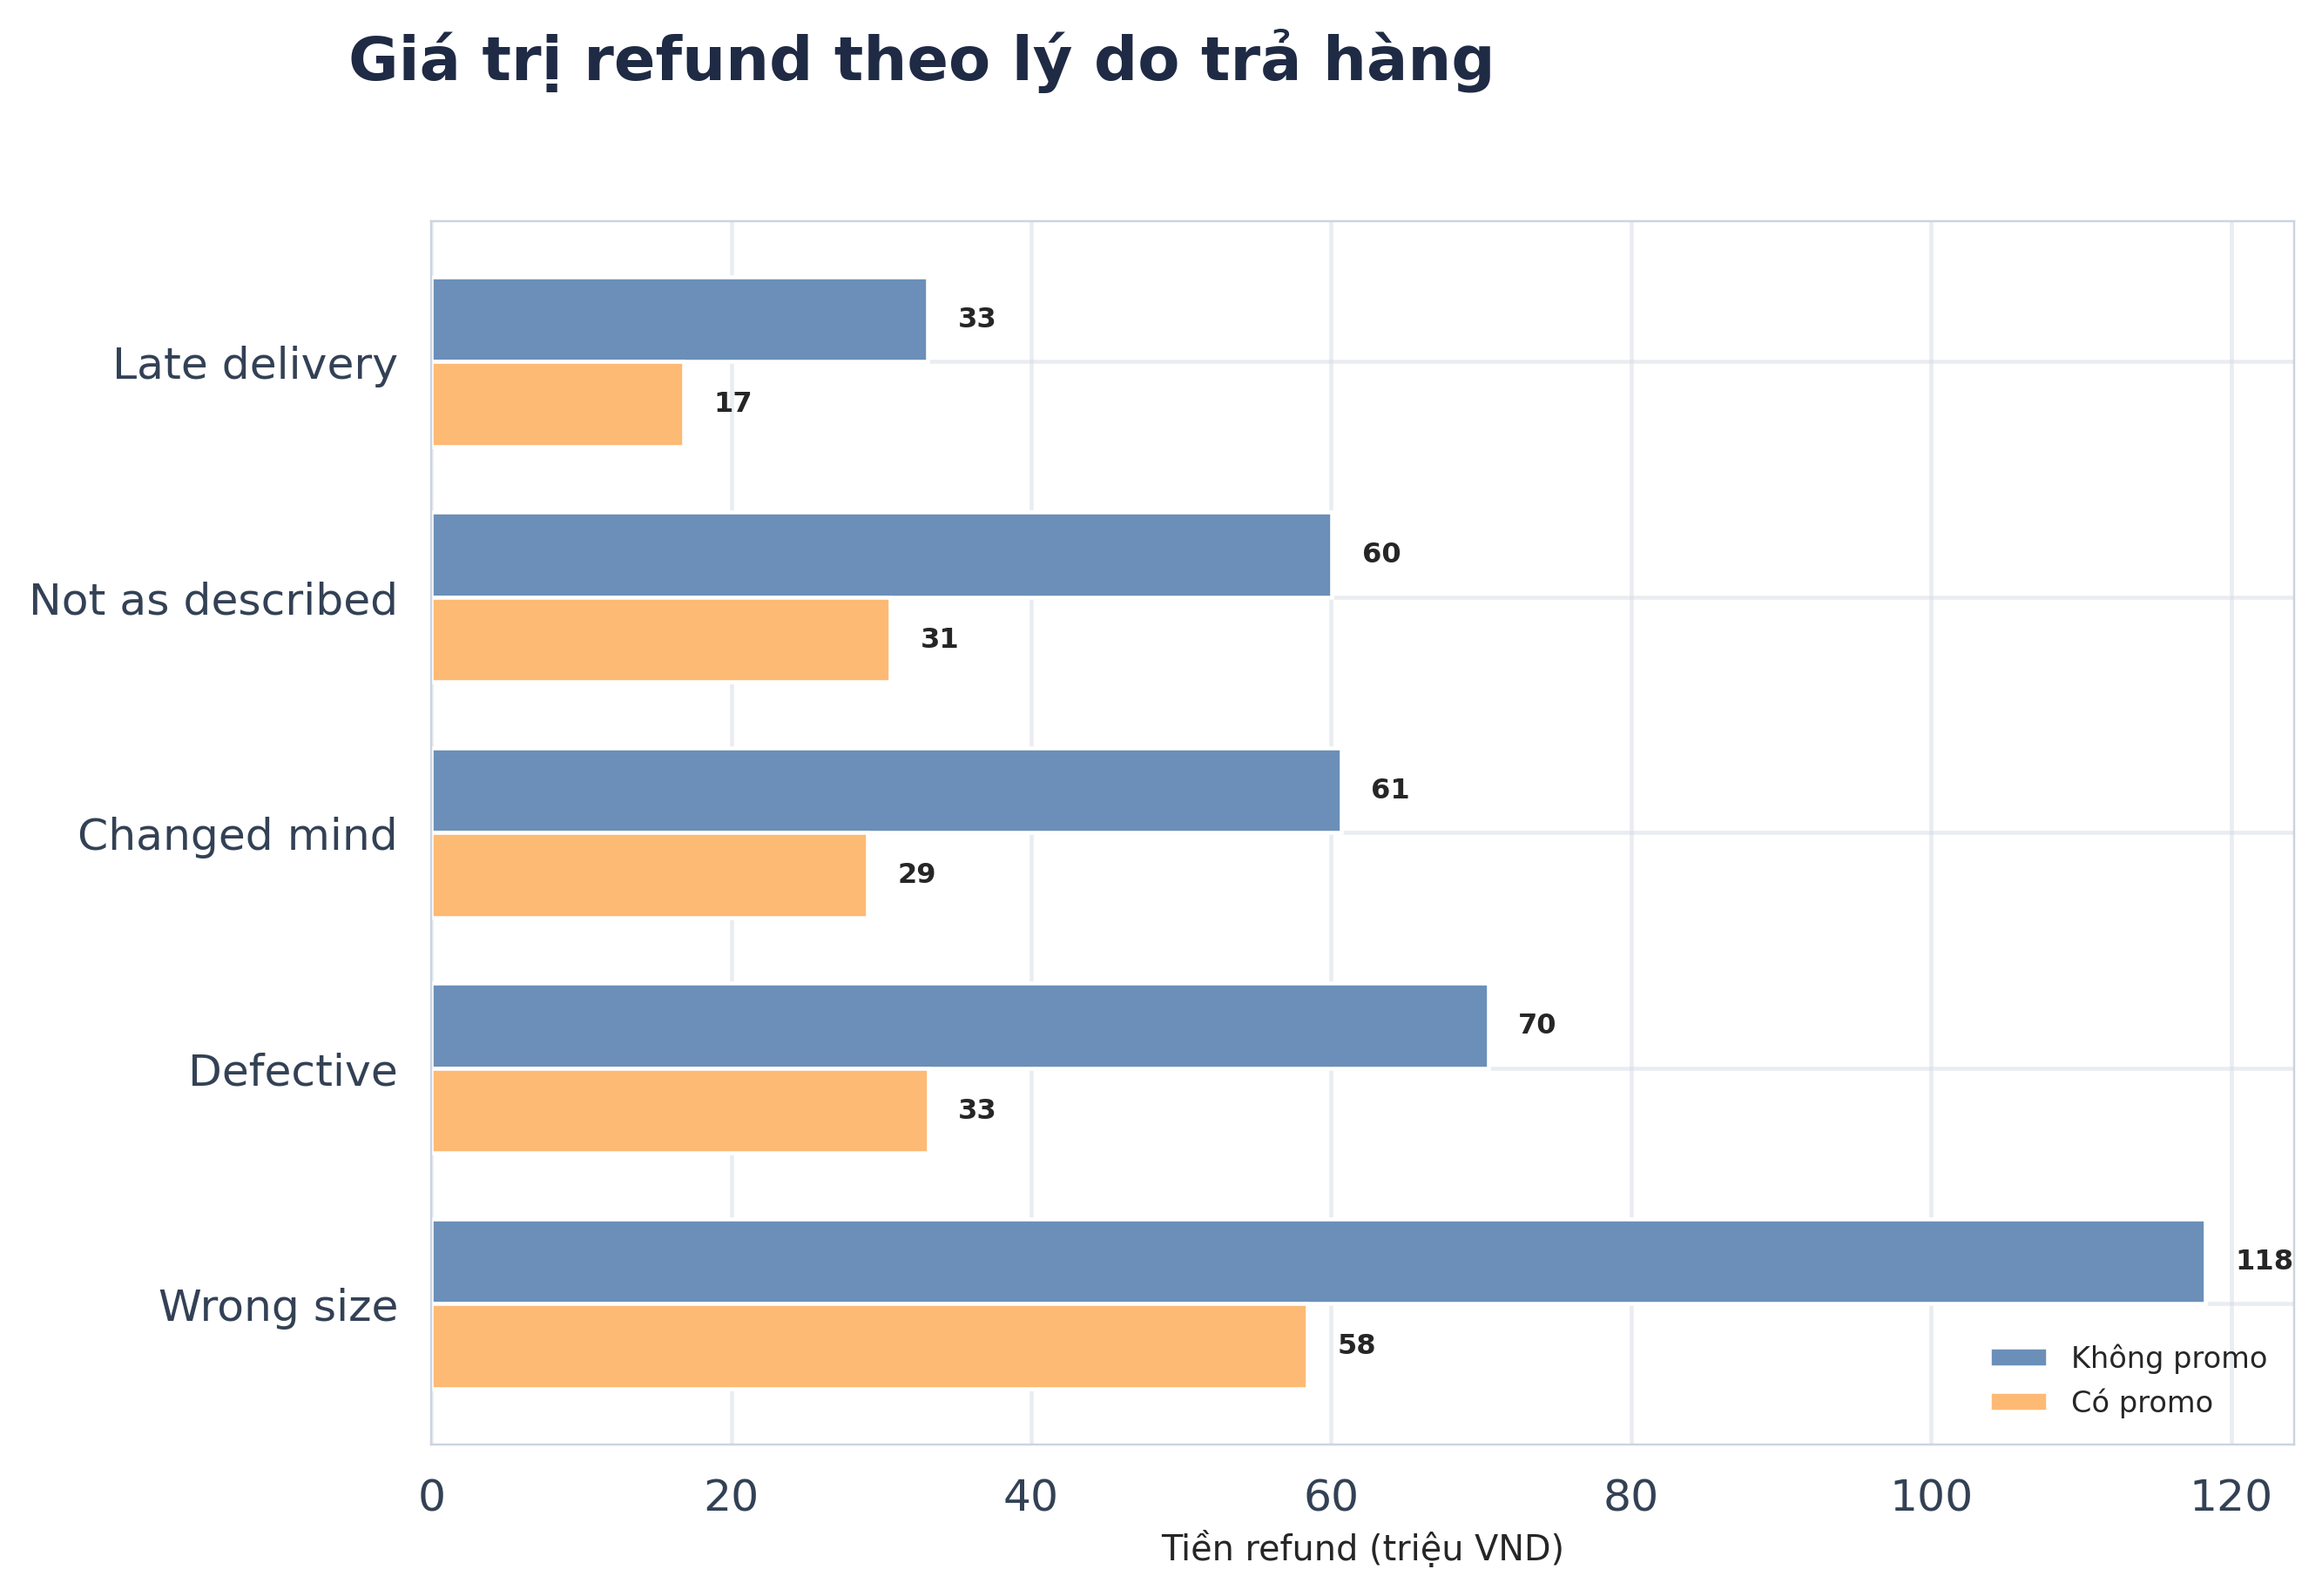

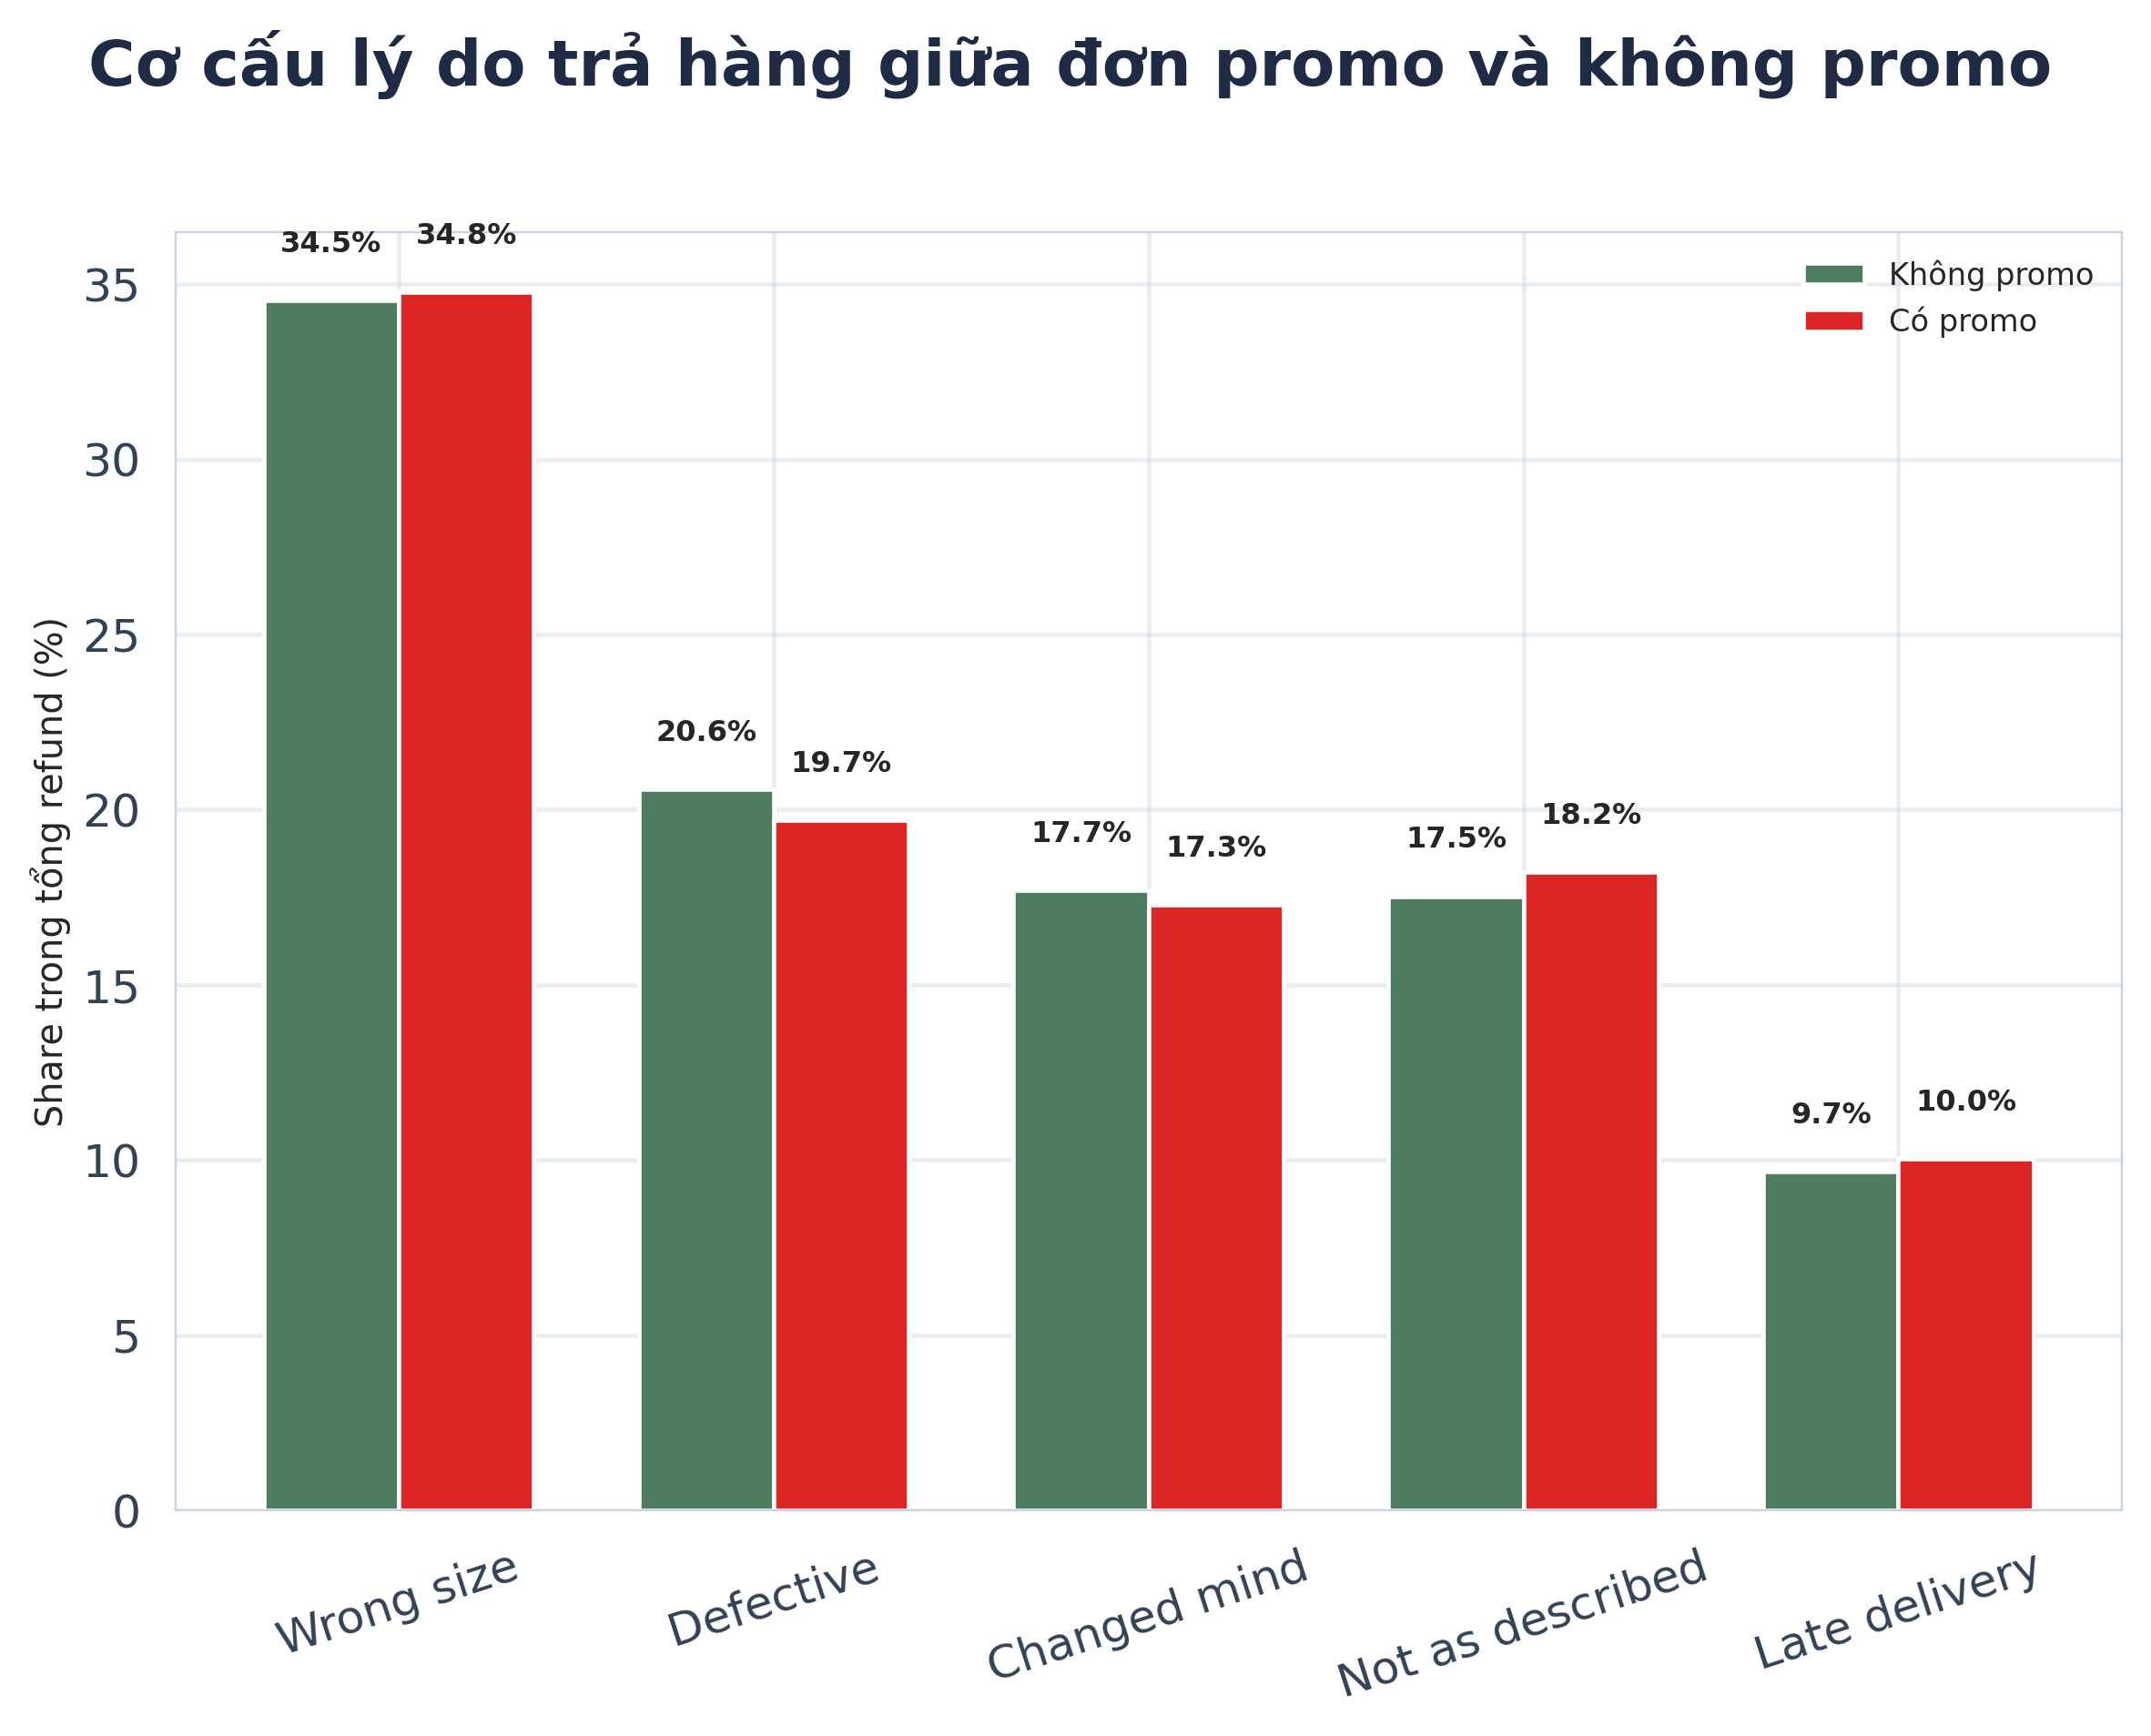

In [2]:
refund_pivot = refund_summary.pivot(index='return_reason', columns='promo_label', values='refund_amount').reindex(reason_order) / 1_000_000
share_pivot = share_summary.pivot(index='return_reason', columns='promo_label', values='share_pct').reindex(reason_order)
reason_labels = {
    'wrong_size': 'Wrong size',
    'defective': 'Defective',
    'changed_mind': 'Changed mind',
    'not_as_described': 'Not as described',
    'late_delivery': 'Late delivery',
}
pretty_labels = [reason_labels[key] for key in reason_order]

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.4))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Giá trị refund theo lý do trả hàng',
    subtitle='',
    encoding_line='',
)
fig.subplots_adjust(left=0.18)
ypos = np.arange(len(reason_order))
height = 0.36
ax.barh(ypos + height / 2, refund_pivot['Không promo'], height=height, color='#6B8FB8', label='Không promo')
ax.barh(ypos - height / 2, refund_pivot['Có promo'], height=height, color='#FDBA74', label='Có promo')
for values, offset in [(refund_pivot['Không promo'], height / 2), (refund_pivot['Có promo'], -height / 2)]:
    for idx, value in enumerate(values):
        ax.text(value + 2, idx + offset, f'{value:.0f}', va='center', fontsize=10.5, fontweight='bold')
ax.set_yticks(ypos)
ax.set_yticklabels(pretty_labels)
ax.set_xlabel('Tiền refund (triệu VND)')
ax.legend(frameon=False, loc='lower right')
refund_path = out_dir / '11_refund_amount_by_reason.png'
save_story_card(fig, refund_path)
display(Image(filename=str(refund_path), width=1100))

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.4))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Cơ cấu lý do trả hàng giữa đơn promo và không promo',
    subtitle='',
    encoding_line='',
)
xpos = np.arange(len(reason_order))
width = 0.36
ax.bar(xpos - width / 2, share_pivot['Không promo'], width=width, color='#4D7C61', label='Không promo')
ax.bar(xpos + width / 2, share_pivot['Có promo'], width=width, color=RED, label='Có promo')
for offset, series in [(-width / 2, share_pivot['Không promo']), (width / 2, share_pivot['Có promo'])]:
    for idx, value in enumerate(series):
        ax.text(idx + offset, value + 1.2, f'{value:.1f}%', ha='center', va='bottom', fontsize=10.5, fontweight='bold')
ax.set_xticks(xpos)
ax.set_xticklabels(pretty_labels, rotation=18)
ax.set_ylabel('Share trong tổng refund (%)')
ax.legend(frameon=False, loc='upper right')
mix_path = out_dir / '12_return_reason_mix.png'
save_story_card(fig, mix_path)
display(Image(filename=str(mix_path), width=1100))


### Ý tưởng phân tích
Tách quy mô refund và cơ cấu lý do trả hàng để kiểm tra xem promotion có thực sự thay đổi hành vi return hay không.

### Phát hiện chính
- Wrong size đứng đầu ở cả quy mô refund lẫn tỷ trọng refund.
- Mix lý do trả hàng giữa nhóm có promo và không promo gần như giữ nguyên.
- Promotion vì thế không giải quyết được gốc rễ của friction hậu mãi.

### Hàm ý kinh doanh
Nếu muốn kéo refund xuống, doanh nghiệp phải sửa bài toán fit/size, mô tả sản phẩm và merchandising. Discount không thể thay cho các can thiệp đó.


## Loyalty concentration và retention sensitivity

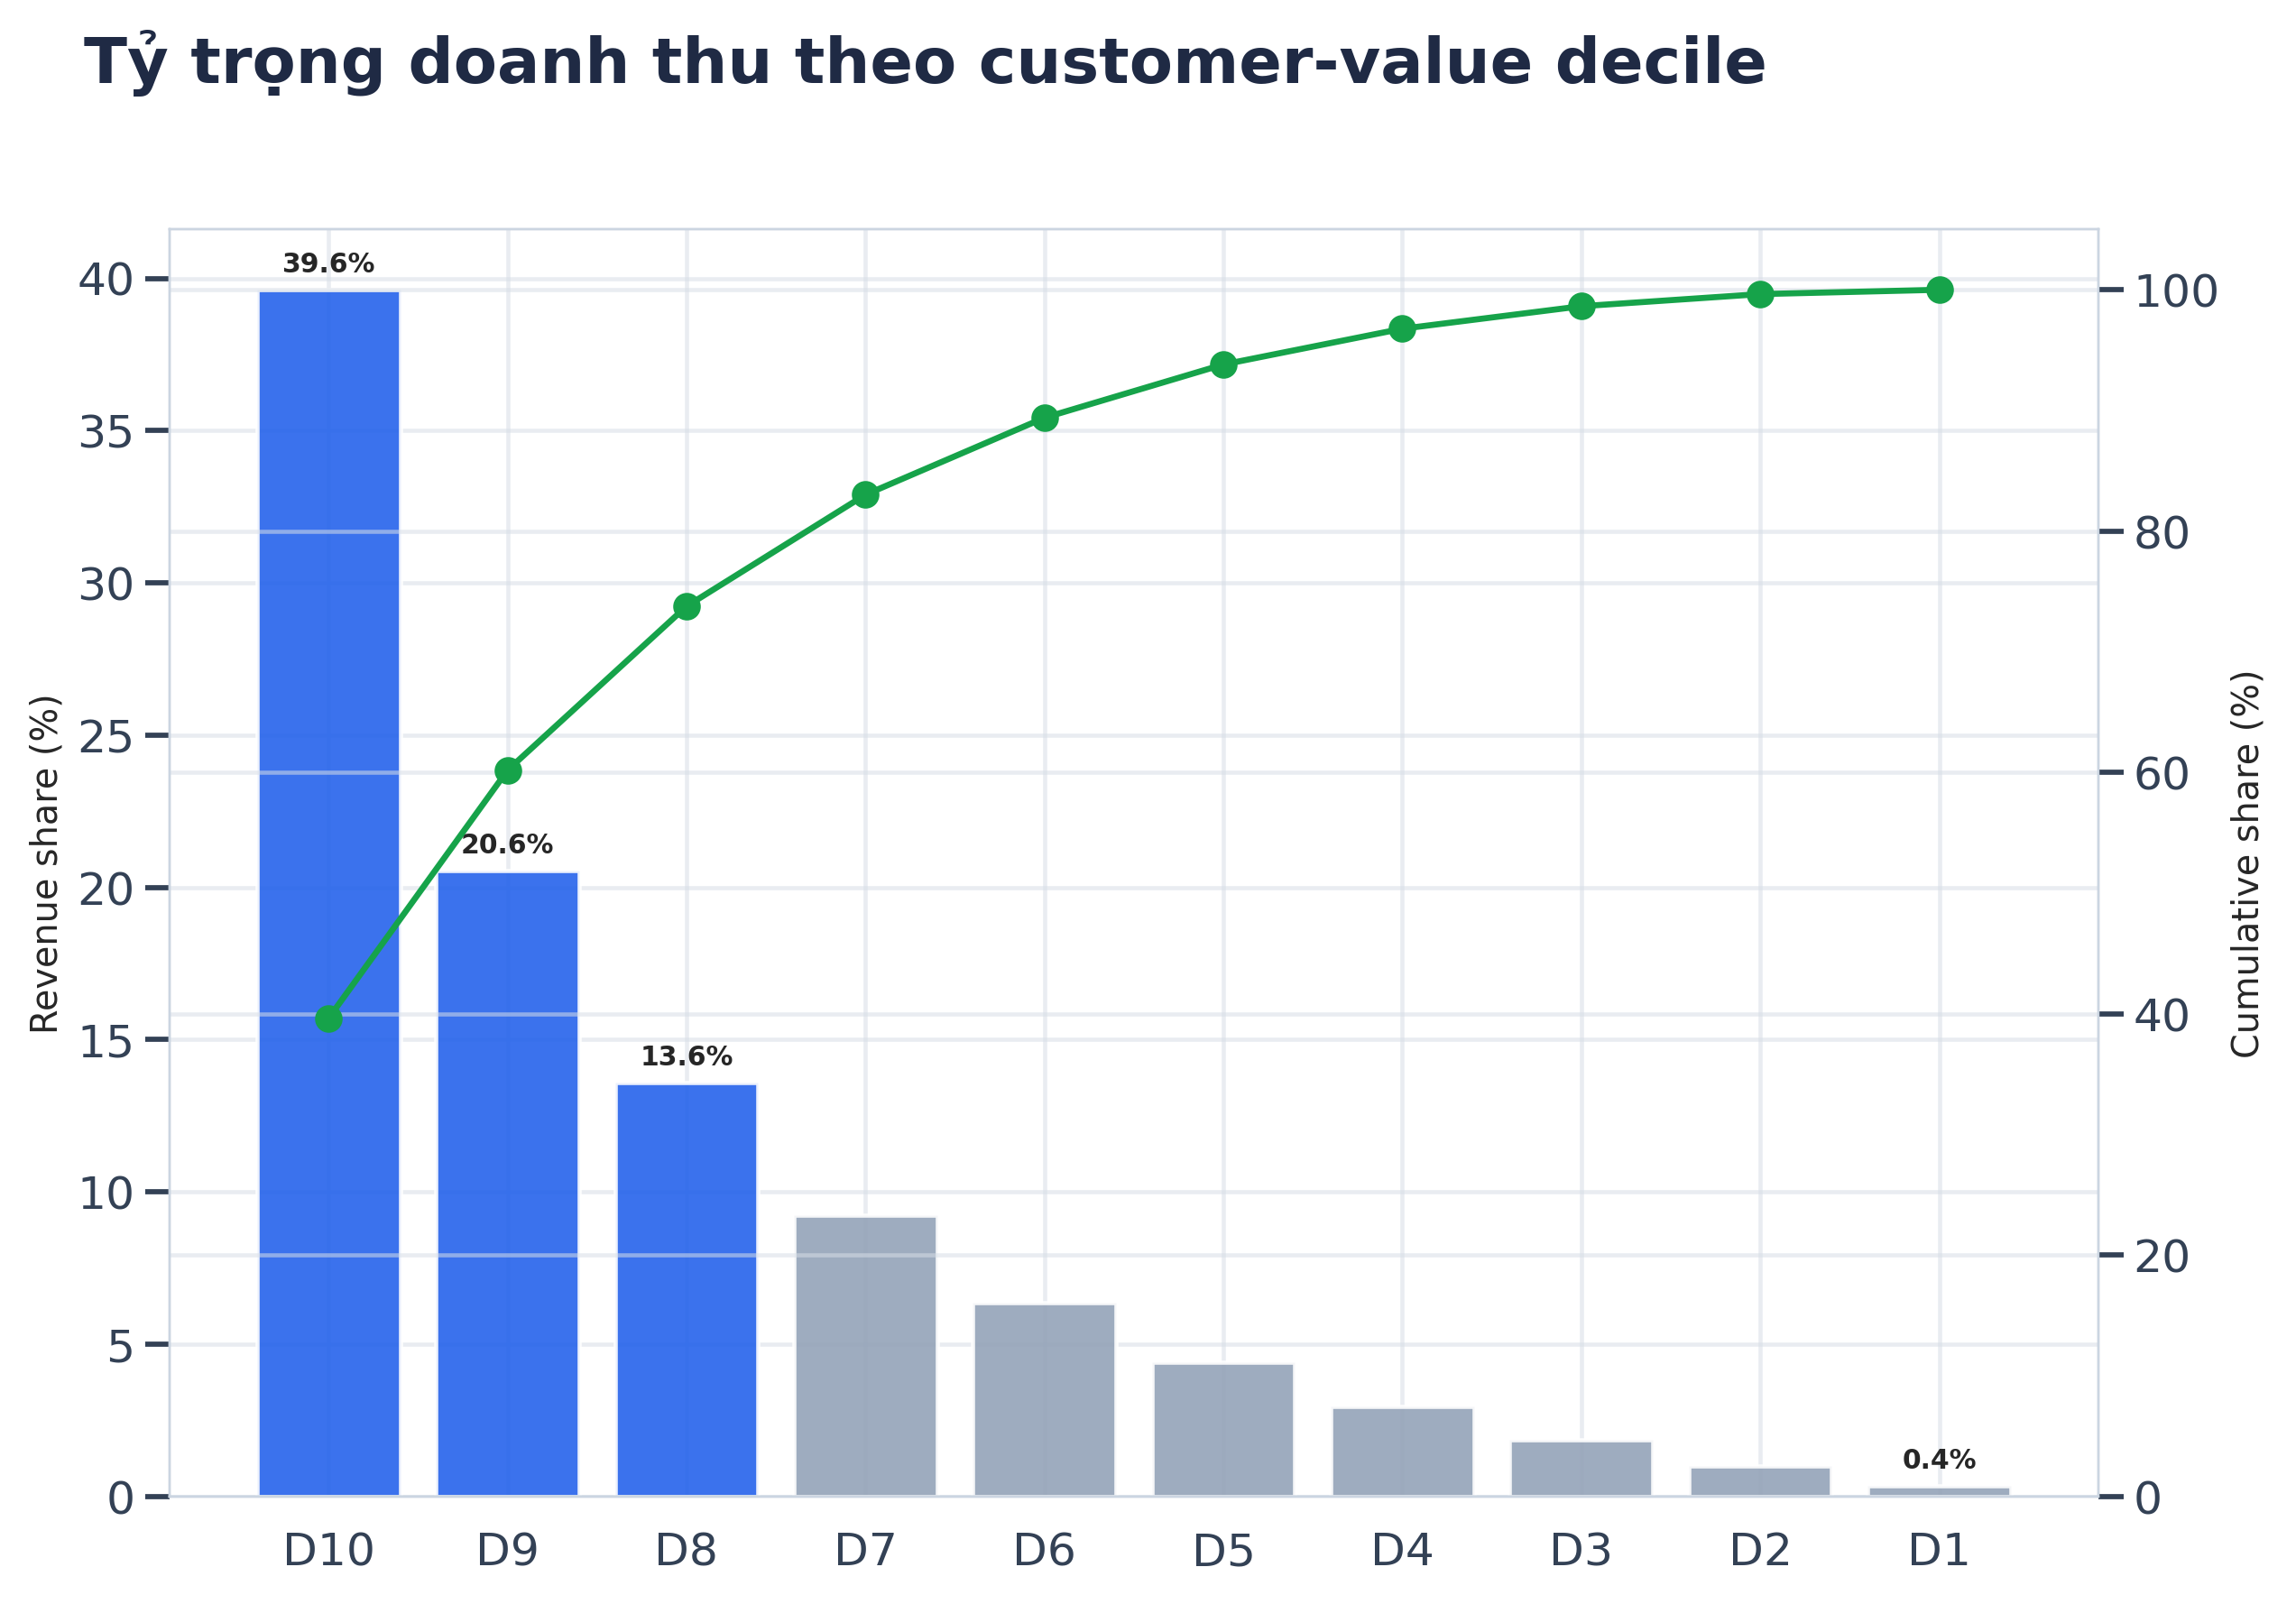

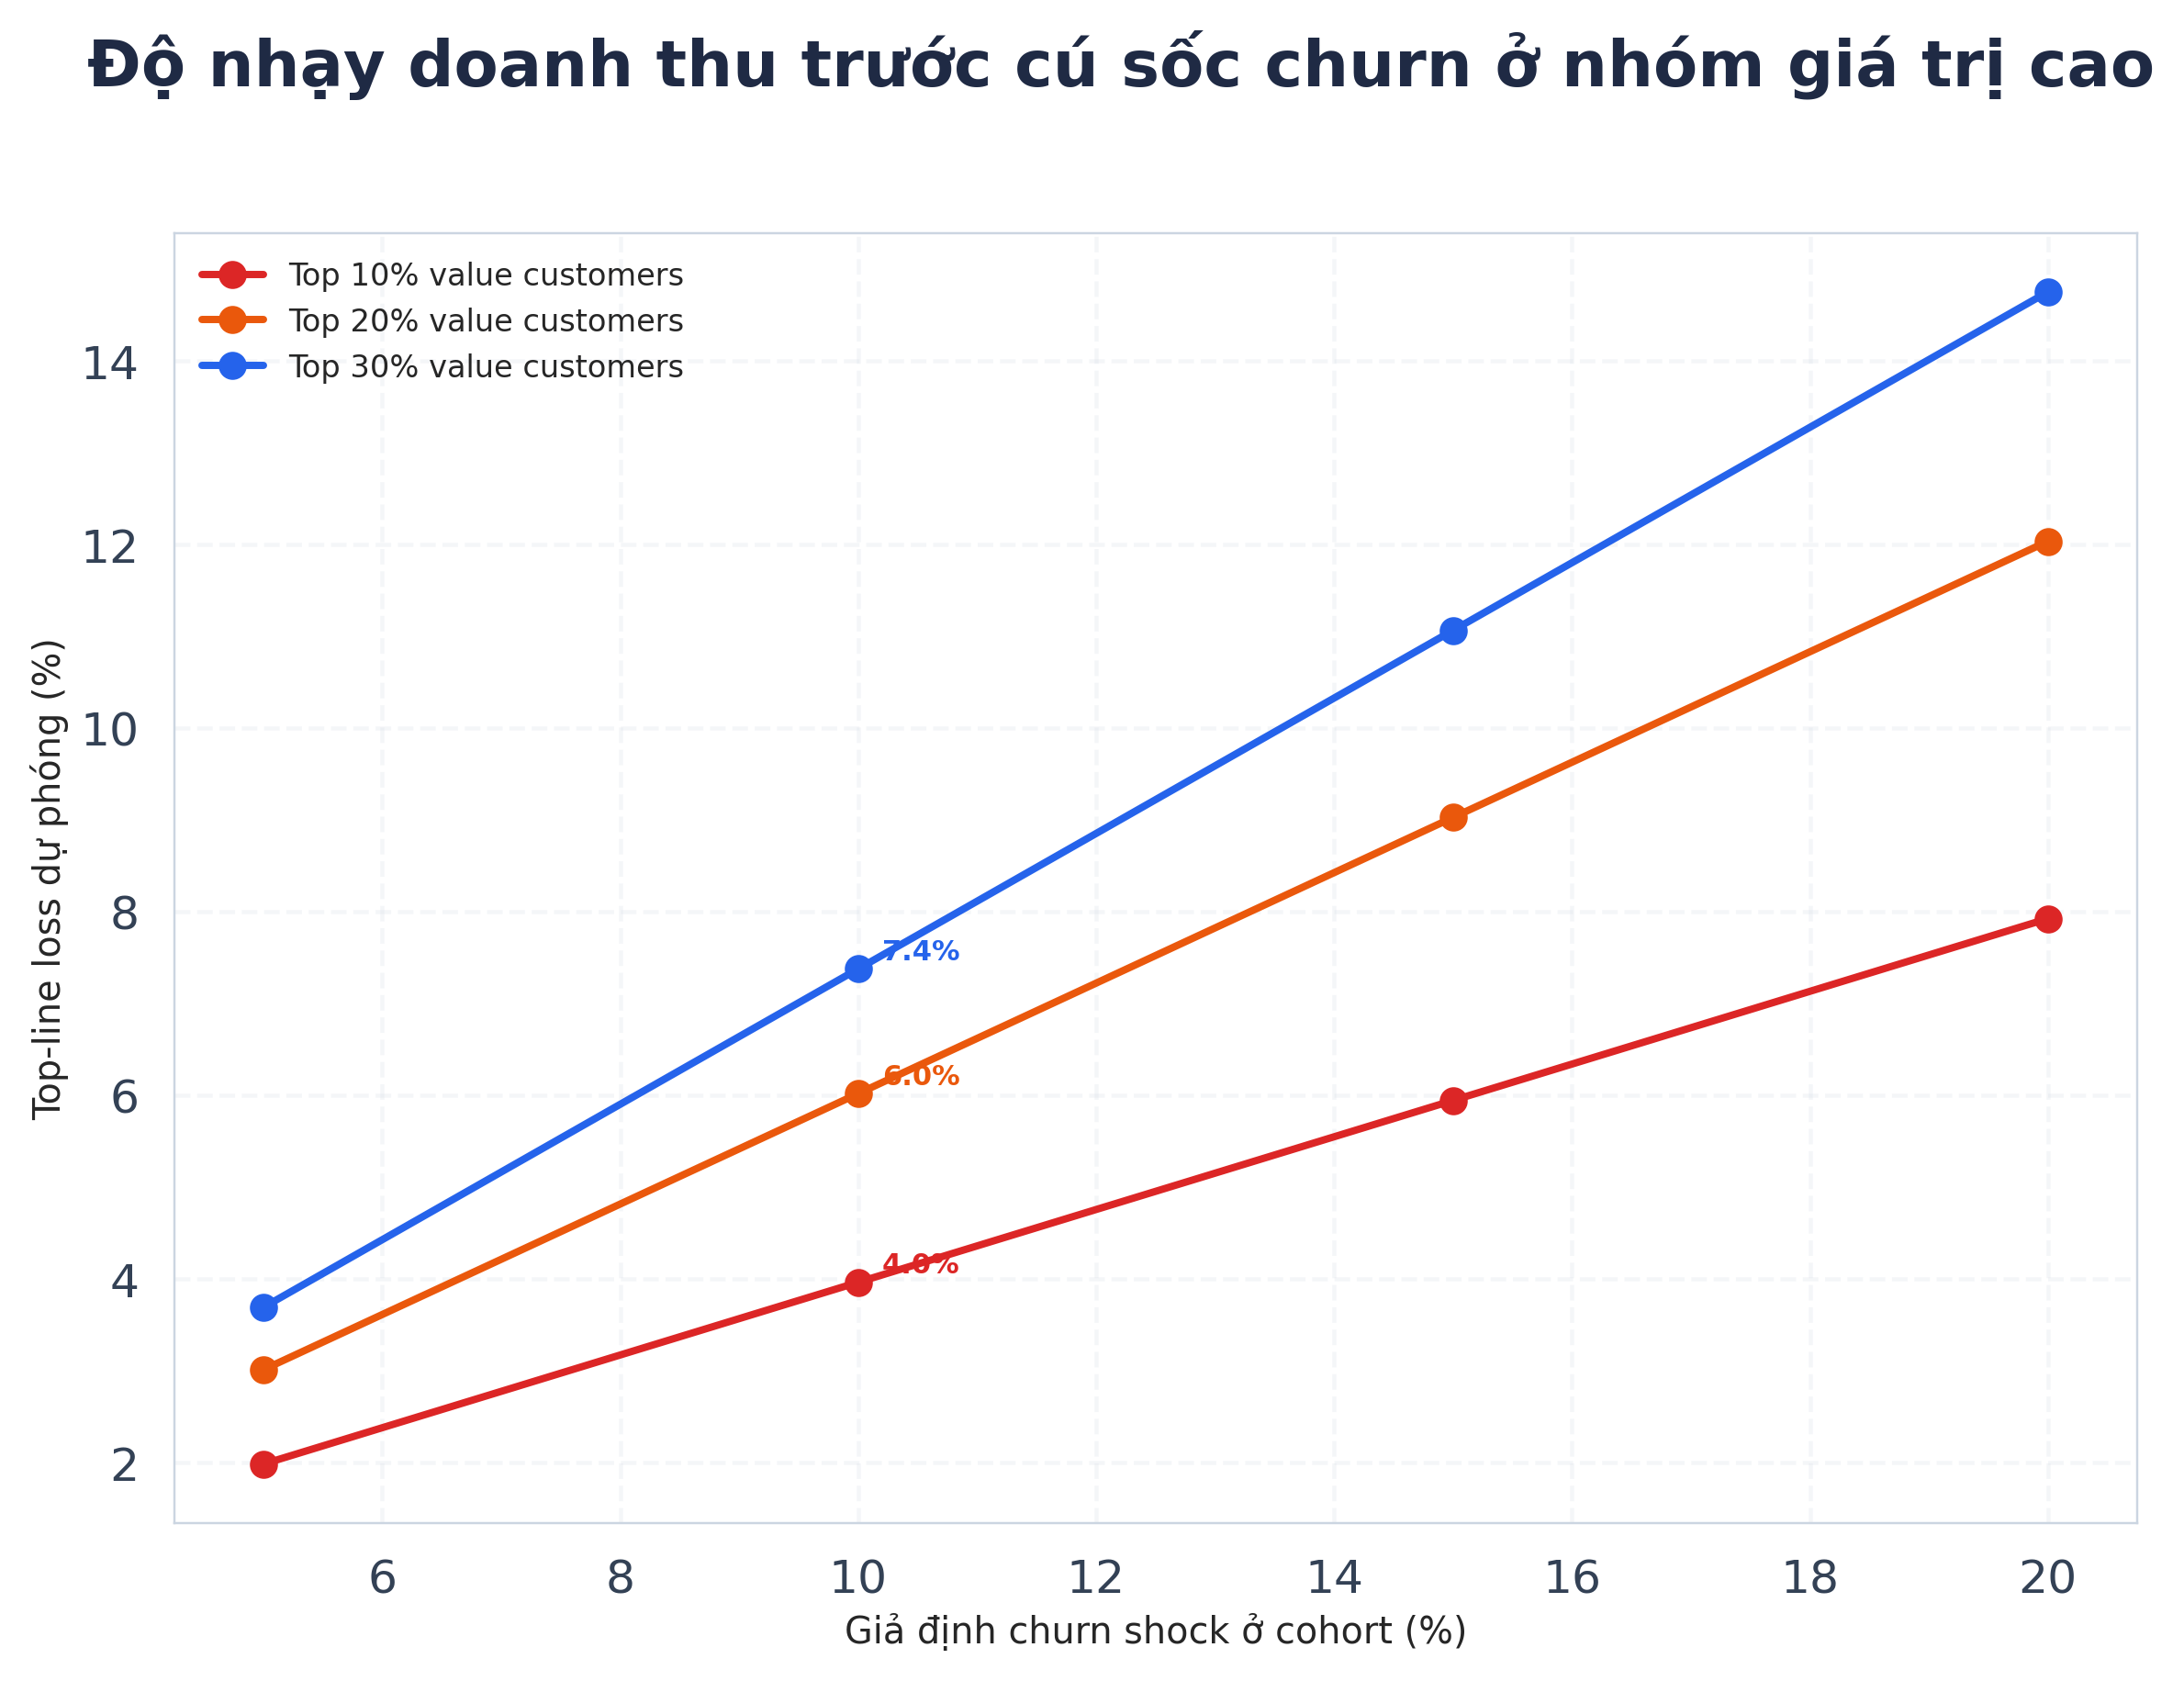

In [3]:
order_revenue = (
    items.groupby('order_id', as_index=False)
    .agg(order_revenue=('net_revenue', 'sum'))
)
order_base = (
    orders[['order_id', 'customer_id', 'order_date', 'order_status']]
    .merge(order_revenue, on='order_id', how='left')
)
order_base['order_revenue'] = order_base['order_revenue'].fillna(0.0)
order_base = order_base.loc[order_base['order_status'] != 'cancelled'].copy()
order_base['order_date'] = pd.to_datetime(order_base['order_date'])

customer_value = (
    order_base.groupby('customer_id', as_index=False)
    .agg(total_revenue=('order_revenue', 'sum'), orders=('order_id', 'count'))
)
customer_value = customer_value.loc[customer_value['total_revenue'] > 0].copy()
customer_value['value_decile'] = pd.qcut(
    customer_value['total_revenue'].rank(method='first'),
    10,
    labels=False,
) + 1
customer_value['value_decile'] = customer_value['value_decile'].astype(int)

revenue_by_decile = (
    customer_value.groupby('value_decile', as_index=False)
    .agg(revenue=('total_revenue', 'sum'), customers=('customer_id', 'nunique'))
)
revenue_by_decile['revenue_share_pct'] = revenue_by_decile['revenue'] / revenue_by_decile['revenue'].sum() * 100
revenue_by_decile = revenue_by_decile.sort_values('value_decile', ascending=False).reset_index(drop=True)
revenue_by_decile['cum_share_pct'] = revenue_by_decile['revenue_share_pct'].cumsum()

first_orders = order_base.sort_values(['customer_id', 'order_date']).copy()
first_orders['order_rank'] = first_orders.groupby('customer_id').cumcount() + 1
first_date = first_orders.groupby('customer_id')['order_date'].min().rename('first_order_date')
first_orders = first_orders.merge(first_date, on='customer_id', how='left')
first_orders['days_from_first'] = (first_orders['order_date'] - first_orders['first_order_date']).dt.days
repeat_within_365 = (
    first_orders.loc[(first_orders['order_rank'] >= 2) & (first_orders['days_from_first'] <= 365)]
    .groupby('customer_id')['order_id']
    .count()
    .rename('repeat_365')
)
customer_value = customer_value.merge(repeat_within_365, on='customer_id', how='left')
customer_value['repeat_365'] = customer_value['repeat_365'].fillna(0)

cohorts = {
    'Top 10% value customers': [10],
    'Top 20% value customers': [9, 10],
    'Top 30% value customers': [8, 9, 10],
}
churn_shocks = np.array([5, 10, 15, 20], dtype=float)

sensitivity_rows = []
for label, deciles in cohorts.items():
    cohort = customer_value.loc[customer_value['value_decile'].isin(deciles)].copy()
    revenue_share = cohort['total_revenue'].sum() / customer_value['total_revenue'].sum() * 100
    repeat_rate = (cohort['repeat_365'] > 0).mean() * 100
    for shock in churn_shocks:
        topline_loss = revenue_share * (shock / 100.0)
        sensitivity_rows.append(
            {
                'cohort': label,
                'shock_pct': shock,
                'revenue_share_pct': revenue_share,
                'repeat_rate_pct': repeat_rate,
                'topline_loss_pct': topline_loss,
            }
        )

sensitivity = pd.DataFrame(sensitivity_rows)

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.4))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Tỷ trọng doanh thu theo customer-value decile',
    subtitle='',
    encoding_line='',
)
x = np.arange(len(revenue_by_decile))
ax.bar(x, revenue_by_decile['revenue_share_pct'], color=[BLUE if d >= 8 else '#94A3B8' for d in revenue_by_decile['value_decile']], alpha=0.9)
for idx, row in revenue_by_decile.iterrows():
    if row['value_decile'] >= 8 or idx in (0, len(revenue_by_decile) - 1):
        ax.text(idx, row['revenue_share_pct'] + 0.4, f"{row['revenue_share_pct']:.1f}%", ha='center', va='bottom', fontsize=9.8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"D{int(v)}" for v in revenue_by_decile['value_decile']])
ax.set_ylabel('Revenue share (%)')
ax_twin = ax.twinx()
ax_twin.plot(x, revenue_by_decile['cum_share_pct'], color=GREEN, marker='o', linewidth=2.2)
ax_twin.set_ylabel('Cumulative share (%)')
ax_twin.set_ylim(0, 105)
conc_path = out_dir / '18_revenue_concentration_by_decile.png'
save_story_card(fig, conc_path)
display(Image(filename=str(conc_path), width=1100))

palette = {
    'Top 10% value customers': RED,
    'Top 20% value customers': ORANGE,
    'Top 30% value customers': BLUE,
}
fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.4))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Độ nhạy doanh thu trước cú sốc churn ở nhóm giá trị cao',
    subtitle='',
    encoding_line='',
)
for cohort, group in sensitivity.groupby('cohort'):
    ax.plot(group['shock_pct'], group['topline_loss_pct'], marker='o', linewidth=2.6, color=palette[cohort], label=cohort)
    row_10 = group.loc[group['shock_pct'] == 10].iloc[0]
    ax.text(10.2, row_10['topline_loss_pct'] + 0.1, f"{row_10['topline_loss_pct']:.1f}%", fontsize=10, color=palette[cohort], fontweight='bold')
ax.set_xlabel('Giả định churn shock ở cohort (%)')
ax.set_ylabel('Top-line loss dự phóng (%)')
ax.legend(frameon=False, loc='upper left')
ax.grid(axis='both', linestyle='--', alpha=0.25)
sens_path = out_dir / '19_retention_sensitivity_high_value.png'
save_story_card(fig, sens_path)
display(Image(filename=str(sens_path), width=1100))


### Ý tưởng phân tích
Để chuyển insight loyalty thành hành động, cần đo đồng thời hai thứ: mức độ tập trung doanh thu vào nhóm khách giá trị cao và độ nhạy top-line khi nhóm đó bị tăng churn.

### Phát hiện chính
Doanh thu tập trung mạnh vào các decile giá trị cao nhất. Khi mô phỏng churn shock ở các cohort top value, top-line loss tăng gần tuyến tính theo mức shock và cao nhất ở nhóm top 10% khách hàng giá trị.

### Hàm ý kinh doanh
Retention cho nhóm khách hàng giá trị cao phải được xem là đòn bẩy chiến lược, không phải hoạt động phụ trợ. Các chương trình chăm sóc, chính sách hoàn/đổi, và trải nghiệm hậu mãi nên ưu tiên theo cohort value trước khi mở rộng đại trà.


## Thử nghiệm. Ma trận trạng thái giữ chân


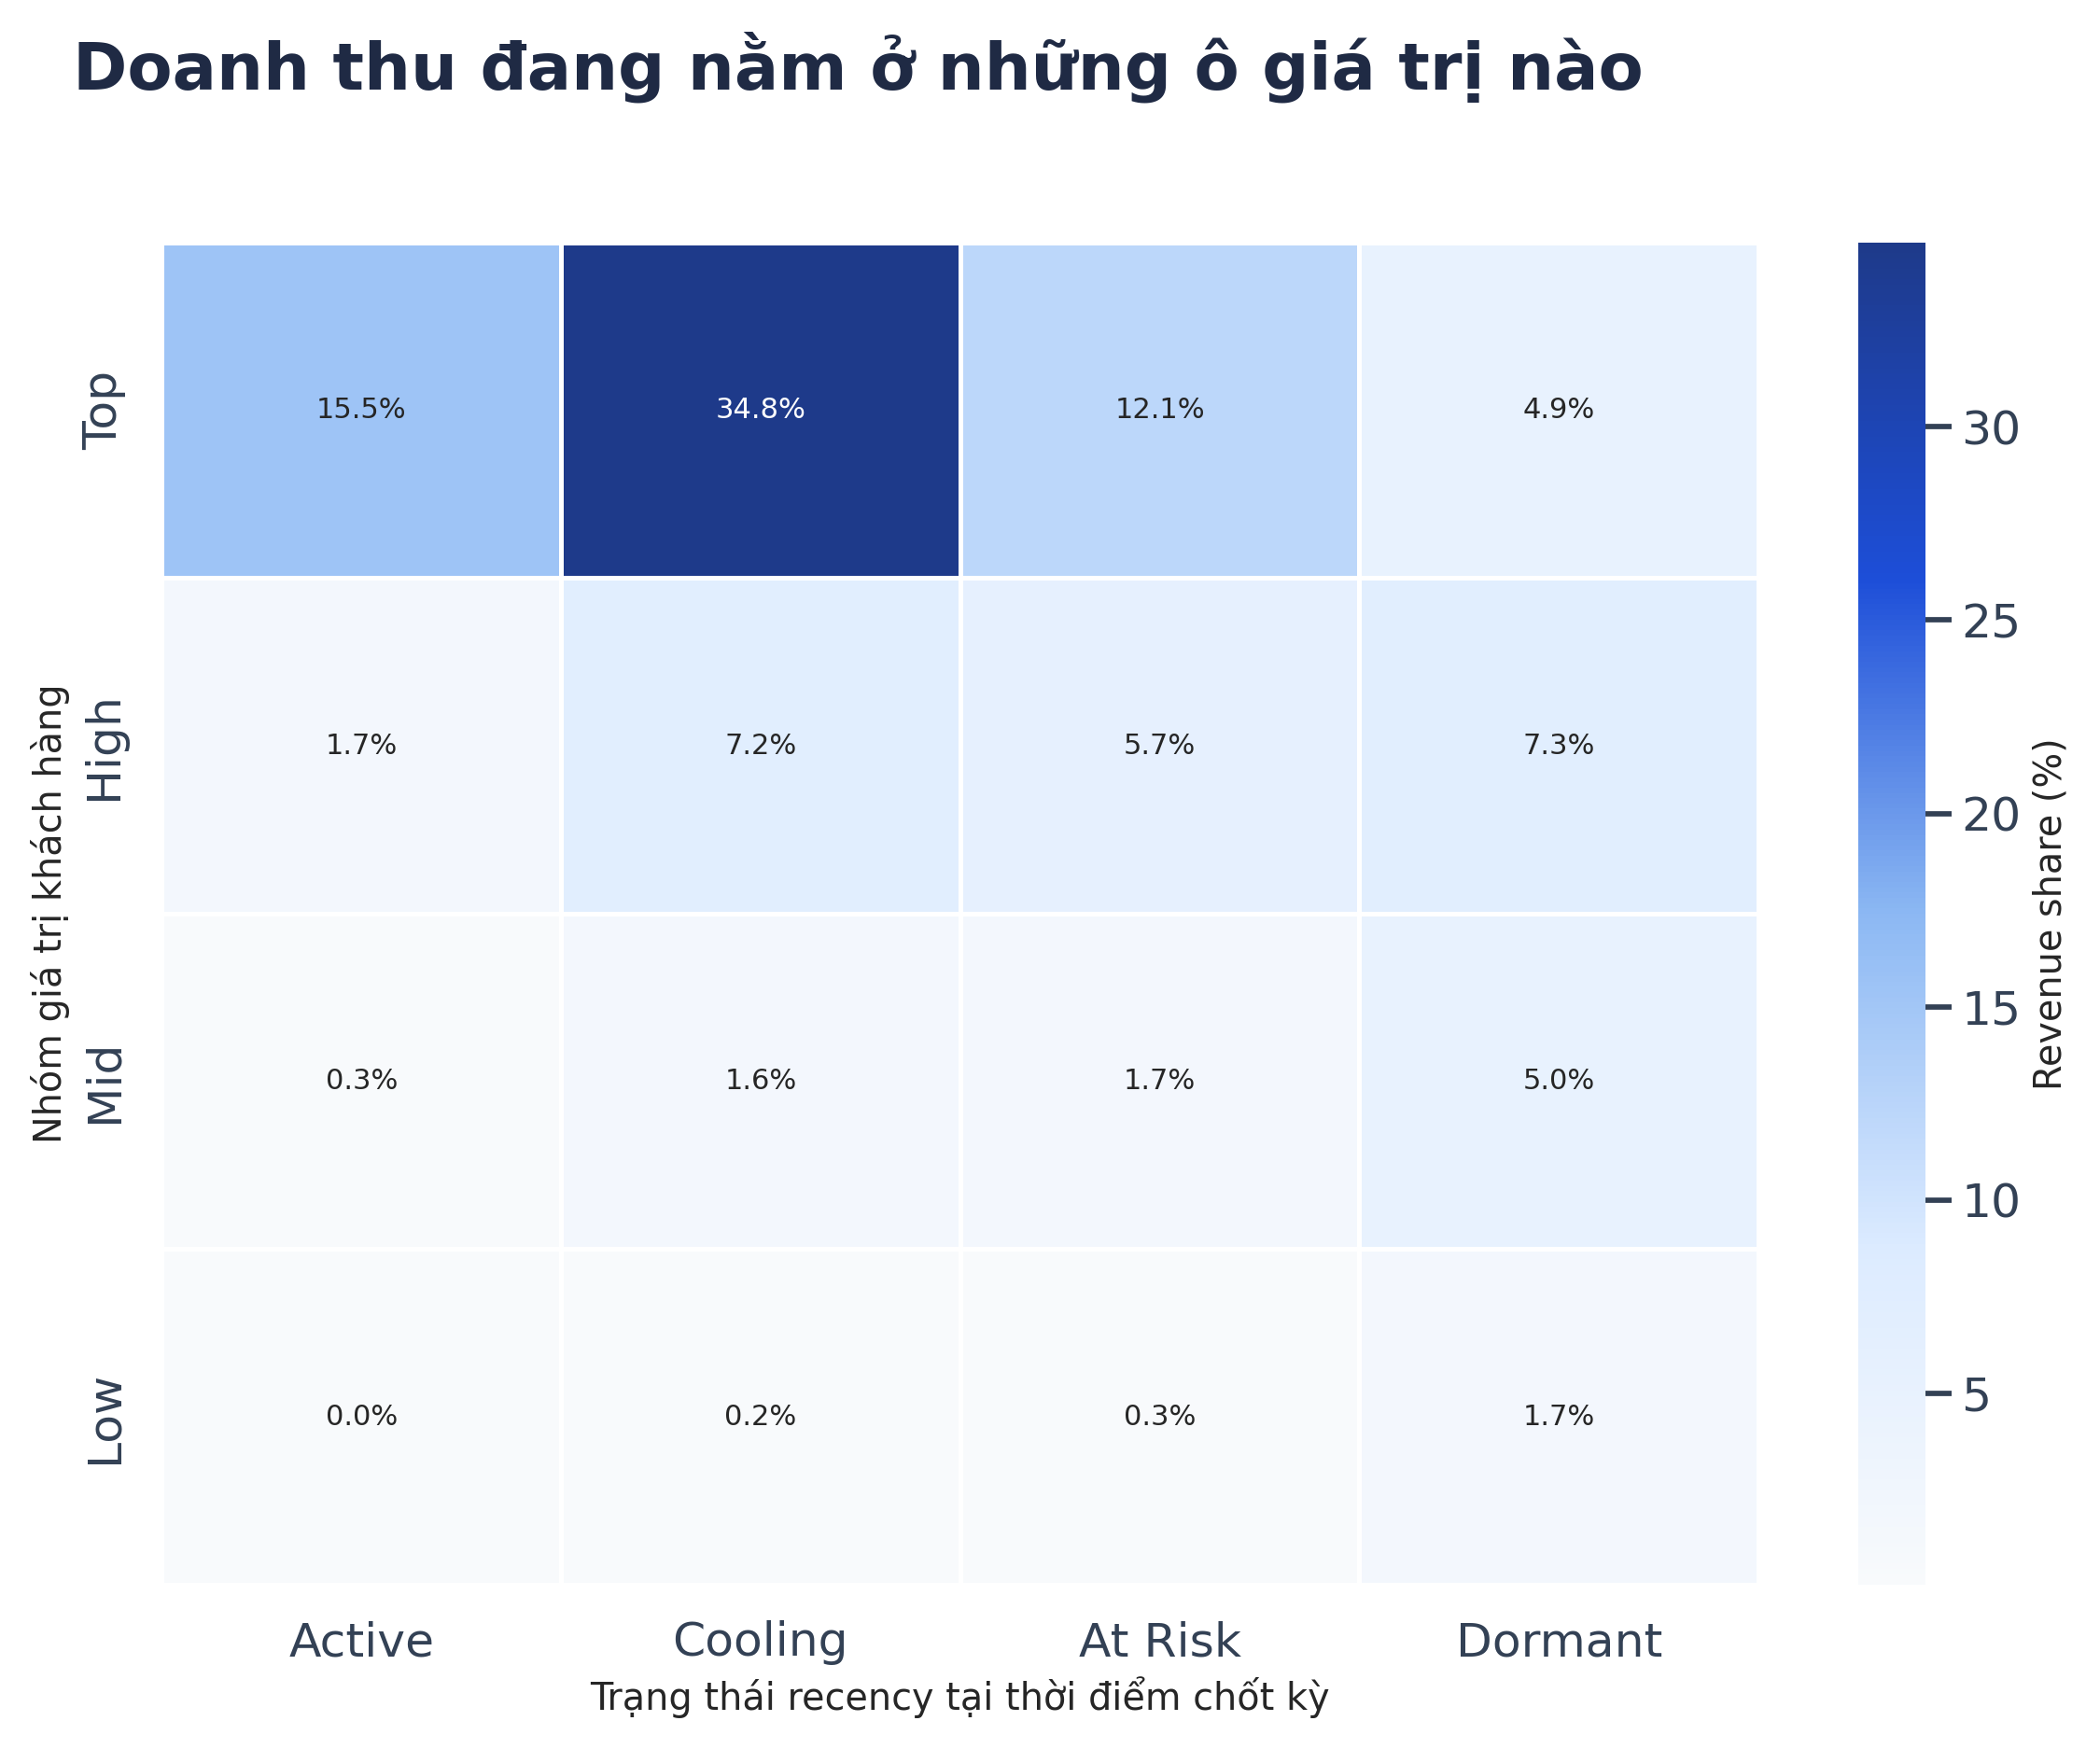

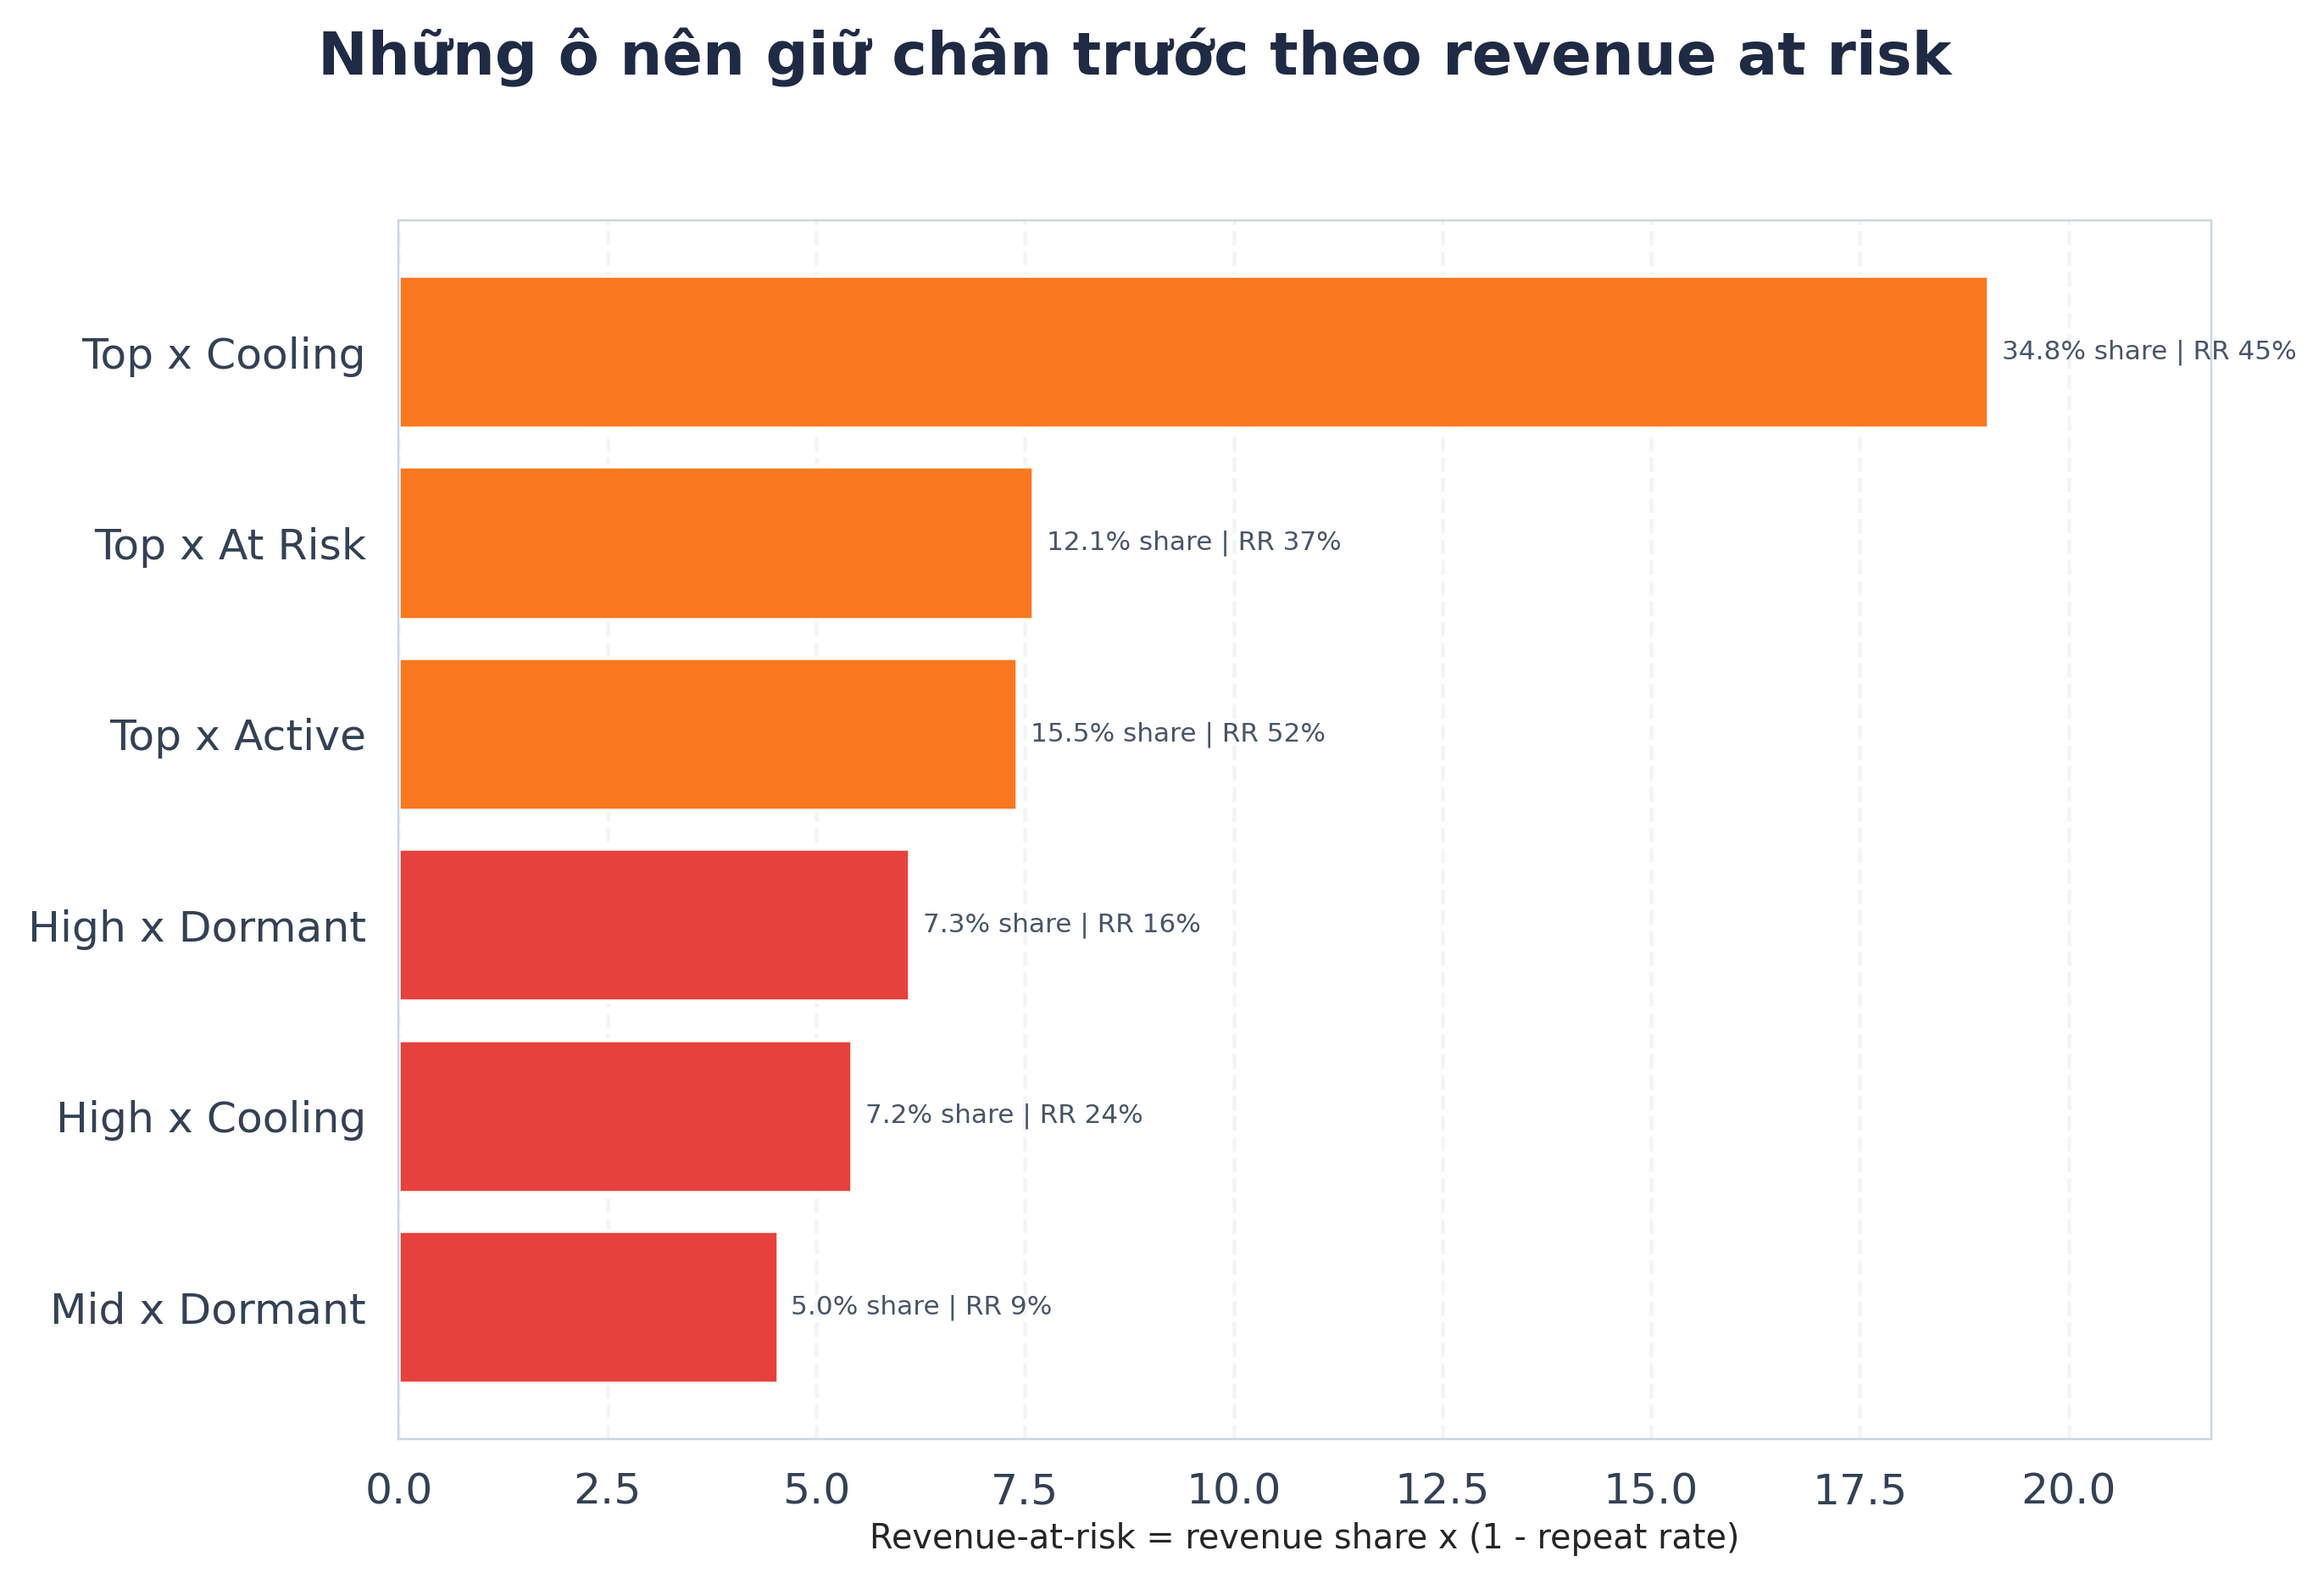

In [4]:
from matplotlib.colors import LinearSegmentedColormap

customer_items = items.merge(orders[['order_id', 'order_date', 'customer_id']], on='order_id', how='left').copy()
customer_orders = (
    customer_items.groupby(['order_id', 'order_date', 'customer_id'])['net_revenue']
    .sum()
    .reset_index(name='order_revenue')
)

retention_rows = []
for cutoff in pd.to_datetime(['2017-12-31', '2018-12-31', '2019-12-31', '2020-12-31', '2021-12-31']):
    history = customer_orders.loc[customer_orders['order_date'].le(cutoff)].copy()
    customer_state = (
        history.groupby('customer_id')
        .agg(revenue=('order_revenue', 'sum'), last_date=('order_date', 'max'))
        .reset_index()
    )
    customer_state['days_since_last'] = (cutoff - customer_state['last_date']).dt.days
    customer_state['recency_band'] = pd.cut(
        customer_state['days_since_last'],
        bins=[-1, 90, 365, 730, 10000],
        labels=['Active', 'Cooling', 'At Risk', 'Dormant'],
    )
    q1, q2, q3 = customer_state['revenue'].quantile([0.25, 0.5, 0.75]).tolist()
    customer_state['value_tier'] = pd.cut(
        customer_state['revenue'],
        bins=[-np.inf, q1, q2, q3, np.inf],
        labels=['Low', 'Mid', 'High', 'Top'],
    )
    future = customer_orders.loc[
        customer_orders['order_date'].between(cutoff + pd.Timedelta(days=1), cutoff + pd.Timedelta(days=180))
    ]
    customer_state['repeat_180'] = customer_state['customer_id'].isin(set(future['customer_id'].unique())).astype(int)
    retention_rows.append(customer_state)

retention_state = pd.concat(retention_rows, ignore_index=True)
retention_summary = (
    retention_state.groupby(['value_tier', 'recency_band'])
    .agg(revenue=('revenue', 'sum'), repeat_rate=('repeat_180', 'mean'))
    .reset_index()
)
retention_summary['revenue_share_pct'] = retention_summary['revenue'] / retention_summary['revenue'].sum() * 100
retention_summary['repeat_pct'] = retention_summary['repeat_rate'] * 100
retention_summary['revenue_at_risk'] = retention_summary['revenue_share_pct'] * (1 - retention_summary['repeat_rate'])

heat = retention_summary.pivot(index='value_tier', columns='recency_band', values='revenue_share_pct').reindex(
    index=['Top', 'High', 'Mid', 'Low'],
    columns=['Active', 'Cooling', 'At Risk', 'Dormant'],
)
annot = retention_summary.assign(
    label=lambda d: d['revenue_share_pct'].map(lambda x: f'{x:.1f}%')
).pivot(index='value_tier', columns='recency_band', values='label').reindex(
    index=['Top', 'High', 'Mid', 'Low'],
    columns=['Active', 'Cooling', 'At Risk', 'Dormant'],
)
focus = retention_summary.sort_values('revenue_at_risk', ascending=False).head(6).copy()
focus['label'] = focus['value_tier'].astype(str) + ' x ' + focus['recency_band'].astype(str)

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.6))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Doanh thu đang nằm ở những ô giá trị nào',
    subtitle='',
    encoding_line='',
)
cmap = LinearSegmentedColormap.from_list('retention_blues', ['#F8FAFC', '#DCEBFF', '#8CB8F3', '#1D4ED8', '#1E3A8A'])
sns.heatmap(
    heat,
    annot=annot,
    fmt='',
    cmap=cmap,
    cbar_kws={'label': 'Revenue share (%)'},
    linewidths=1,
    linecolor='white',
    ax=ax,
    annot_kws={'fontsize': 10},
)
ax.set_xlabel('Trạng thái recency tại thời điểm chốt kỳ')
ax.set_ylabel('Nhóm giá trị khách hàng')
heat_path = out_dir / 'exp_retention_revenue_share_matrix.png'
save_story_card(fig, heat_path)
display(Image(filename=str(heat_path), width=1100))

focus = focus.sort_values('revenue_at_risk')
colors = np.where(focus['repeat_pct'] >= focus['repeat_pct'].median(), '#F97316', '#E53935')
fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.6))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Những ô nên giữ chân trước theo revenue at risk',
    subtitle='',
    encoding_line='',
)
ax.barh(focus['label'], focus['revenue_at_risk'], color=colors, alpha=0.96)
for y, (_, row) in enumerate(focus.iterrows()):
    ax.text(row['revenue_at_risk'] + 0.16, y, f"{row['revenue_share_pct']:.1f}% share | RR {row['repeat_pct']:.0f}%", va='center', fontsize=10.2, color='#475569')
ax.set_xlabel('Revenue-at-risk = revenue share x (1 - repeat rate)')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)
ax.set_xlim(0, focus['revenue_at_risk'].max() * 1.14)
rank_path = out_dir / 'exp_retention_priority_rank.png'
save_story_card(fig, rank_path)
display(Image(filename=str(rank_path), width=1100))


### Ý tưởng phân tích
Chart này tách rõ hai câu hỏi thay vì nhồi cả hai vào một ô heatmap. Panel A chỉ cho biết doanh thu đang nằm ở đâu giữa các nhóm giá trị và trạng thái recency. Vì vậy, người đọc nhìn vào là biết ngay doanh thu đang tập trung ở ô nào mà không cần đọc thêm xác suất mua lại trong cùng một ô.

Panel B mới là phần predictive. `revenue_at_risk` được tính rất đơn giản bằng `revenue share x (1 - repeat rate)`, nên có thể hiểu như lượng doanh thu hiện hữu đang dễ mỏng đi nếu không có hành động giữ chân. Annotation chỉ giữ lại hai số cần thiết nhất là thị phần doanh thu và `RR` tức repeat rate. Cách tách này giúp chart dễ đọc hơn nhiều so với việc nhét cả doanh thu lẫn xác suất lặp lại vào cùng một tile.